# ***Ⅲ. 이미지 데이터 처리***
## ***04. 이미지 데이터의 분류 응용***
- 해밍거리를 응용해 틀린그림 찾기를 해봅니다
- 이미지 밝기 조절을 이용해 MNIST데이터셋을 개선하고 우리의 손글씨를 인식시켜봅니다

In [6]:
# imshow함수 준비
import cv2
import numpy as np
from matplotlib import pyplot as plt

def cv2_imshow(img, title='Image', figsize=(5,5), axis='on'):
    # BGR -> RGB 변환
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis(axis)
    plt.show()

## ***랜덤 시드 초기화***
- 랜덤 패턴의 시작값을 동일하게 하면 동일한 랜덤 패턴을 얻을 수 있습니다

In [14]:
np.random.seed(42)

### ***5x5 흑백 이미지 틀린픽셀 찾기***

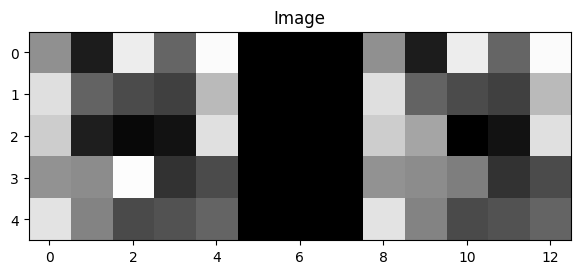

In [67]:
import numpy as np
import cv2

# 랜덤 흑백 이미지 생성
H, W = 5, 5
base = np.random.randint(0, 256, (H, W), dtype=np.uint8)
modified = base.copy()

for _ in range(3):
    # 랜덤 위치
    y = np.random.randint(1, H-1)
    x = np.random.randint(1, W-1)

    # 값 살짝 변경 (밝게 or 어둡게)
    delta = np.random.randint(100, 150) * np.random.choice([-1, 1])

    modified[y:y+1, x:x+1] = np.clip(
        modified[y:y+1, x:x+1] + delta,
        0, 255
    )

# 중간 마진 (검정 띠)
gap = np.zeros((H, 3), dtype=np.uint8)

# 좌-마진-우 합치기
vis = np.hstack([base, gap, modified])

cv2_imshow(vis,figsize=(7,7))

### ***해밍 거리를 응용한 틀린 픽셀 찾기***

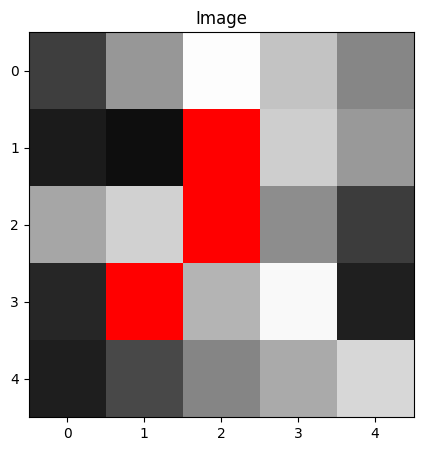

In [58]:
# 픽셀 차이가 있으면 True -> 숫자로 변환 -> 1
diff = (base != modified).astype(np.uint8)

# True인 좌표 추출
ys, xs = np.where(diff == 1)

# 시각화
vis = cv2.cvtColor(base.copy(), cv2.COLOR_GRAY2BGR)
vis[ys, xs] = [0, 0, 255]

cv2_imshow(vis)

### ***10x10 흑백 이미지 틀린픽셀 찾기***

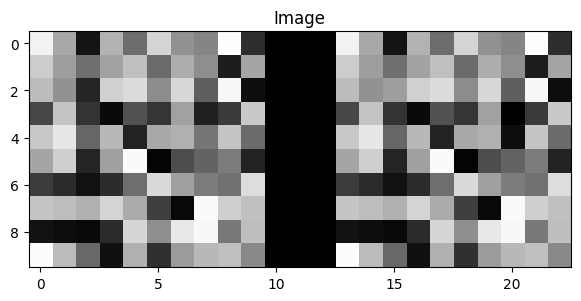

In [70]:
import numpy as np
import cv2

# 랜덤 흑백 이미지 생성
H, W = 10, 10
base = np.random.randint(0, 256, (H, W), dtype=np.uint8)
modified = base.copy()

for _ in range(3):
    # 랜덤 위치
    y = np.random.randint(2, H-2)
    x = np.random.randint(2, W-2)

    # 값 살짝 변경 (밝게 or 어둡게)
    delta = np.random.randint(100, 150) * np.random.choice([-1, 1])

    modified[y:y+1, x:x+1] = np.clip(
        modified[y:y+1, x:x+1] + delta,
        0, 255
    )

# 중간 마진 (검정 띠)
gap = np.zeros((H, 3), dtype=np.uint8)

# 좌-마진-우 합치기
vis = np.hstack([base, gap, modified])

cv2_imshow(vis,figsize=(7,7))

### ***해밍 거리를 응용한 틀린 픽셀 찾기***

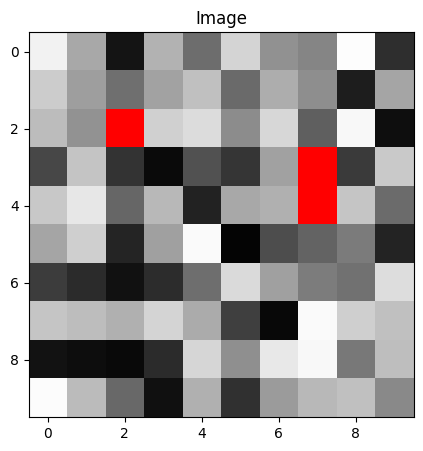

In [71]:
# 픽셀 차이가 있으면 True -> 숫자로 변환 -> 1
diff = (base != modified).astype(np.uint8)

# True인 좌표 추출
ys, xs = np.where(diff == 1)

# 시각화
vis = cv2.cvtColor(base.copy(), cv2.COLOR_GRAY2BGR)
vis[ys, xs] = [0, 0, 255]

cv2_imshow(vis)

## ***200x200 이미지***

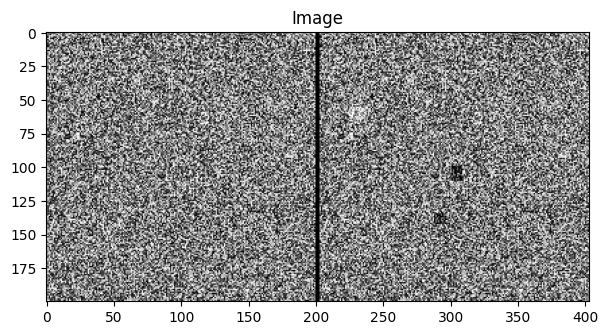

In [73]:
import numpy as np
import cv2

# 랜덤 흑백 이미지 생성
H, W = 200, 200
base = np.random.randint(0, 256, (H, W), dtype=np.uint8)
modified = base.copy()

for _ in range(3):
    # 랜덤 위치
    y = np.random.randint(20, H-20)
    x = np.random.randint(20, W-20)

    # 랜덤한 작은 사각형 영역
    h, w = np.random.randint(5, 15), np.random.randint(5, 15)

    # 값 살짝 변경 (밝게 or 어둡게)
    delta = np.random.randint(50, 120) * np.random.choice([-1, 1])

    modified[y:y+h, x:x+w] = np.clip(
        modified[y:y+h, x:x+w] + delta,
        0, 255
    )

gap = np.zeros((H, 3), dtype=np.uint8)
vis = np.hstack([base, gap, modified])

cv2_imshow(vis,figsize=(7,7))

### ***해밍 거리를 응용한 틀린 픽셀 찾기***

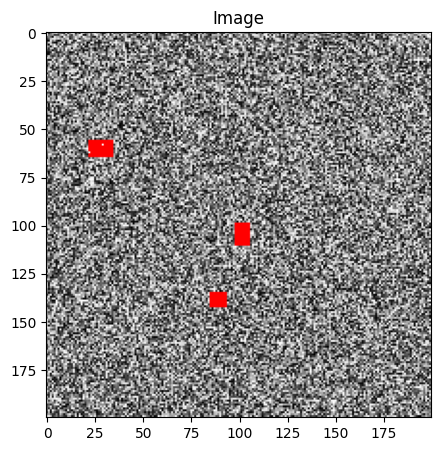

In [74]:
# 픽셀 차이가 있으면 True -> 숫자로 변환 -> 1
diff = (base != modified).astype(np.uint8)

# True인 좌표 추출
ys, xs = np.where(diff == 1)

# 시각화
vis = cv2.cvtColor(base.copy(), cv2.COLOR_GRAY2BGR)
vis[ys, xs] = [0, 0, 255]

cv2_imshow(vis)

## ***해밍 거리를 이용한 틀린 그림 찾기***
- 이제 컬러 이미지로 들어갑니다
- ```같은 그림이라도 색상 값이 정확하게 같지 않을 수도 있습니다```

In [ ]:
# 이미지 출처: https://en.wikipedia.org/wiki/Spot_the_difference
! wget https://upload.wikimedia.org/wikipedia/commons/thumb/0/0a/Spot_the_difference.png/500px-Spot_the_difference.png

--2026-05-16 16:41:28--  https://upload.wikimedia.org/wikipedia/commons/thumb/0/0a/Spot_the_difference.png/500px-Spot_the_difference.png
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 240582 (235K) [image/png]
Saving to: ‘500px-Spot_the_difference.png’

500px-Spot_the_diff 100%[===================>] 234.94K   714KB/s    in 0.3s    

2026-05-16 16:41:29 (714 KB/s) - ‘500px-Spot_the_difference.png’ saved [240582/240582]



In [ ]:
import cv2

# 이미지 출처: https://en.wikipedia.org/wiki/Spot_the_difference
img = cv2.imread('500px-Spot_the_difference.png')

img

array([[[ 50, 153,   0],
        [ 48, 152,   0],
        [ 48, 152,   0],
        ...,
        [ 48, 152,   0],
        [ 48, 152,   0],
        [ 48, 152,   0]],

       [[ 48, 152,   0],
        [ 77, 166,  70],
        [100, 177, 128],
        ...,
        [ 98, 177, 125],
        [100, 177, 128],
        [ 77, 166,  70]],

       [[ 47, 152,   0],
        [100, 177, 128],
        [141, 198, 234],
        ...,
        [139, 197, 228],
        [141, 198, 234],
        [100, 177, 128]],

       ...,

       [[ 47, 153,   0],
        [107, 144,  85],
        [110, 108, 119],
        ...,
        [131,  50,   0],
        [133,  47,   0],
        [ 95,  95,   0]],

       [[ 49, 154,   0],
        [ 50, 121,  18],
        [ 53, 100,  36],
        ...,
        [ 94,  96,   0],
        [ 95,  95,   0],
        [ 74, 121,   0]],

       [[ 49, 152,   0],
        [ 50, 154,   0],
        [ 50, 155,   0],
        ...,
        [ 48, 155,   0],
        [ 48, 155,   0],
        [ 49, 154,   0]]

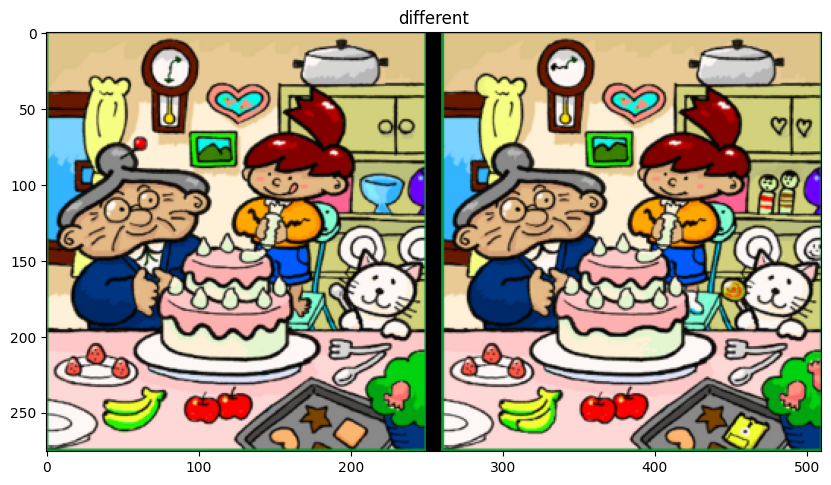

In [86]:
left_img = img[:, :250]
right_img = img[:, 250:]

H = img.shape[0]
gap = np.zeros((H, 10, 3), dtype=np.uint8)
vis = np.hstack([left_img, gap, right_img])
cv2_imshow(vis, "different", figsize=(10,10))

## ***픽셀 수준의 동일여부 확인***

In [87]:
left_img != right_img

array([[[False, False, False],
        [ True, False, False],
        [False, False, False],
        ...,
        [False, False, False],
        [False, False, False],
        [ True, False, False]],

       [[ True, False, False],
        [ True,  True,  True],
        [ True,  True,  True],
        ...,
        [False, False, False],
        [ True,  True,  True],
        [ True,  True,  True]],

       [[ True, False, False],
        [ True,  True,  True],
        [ True,  True,  True],
        ...,
        [False, False,  True],
        [ True,  True,  True],
        [ True,  True,  True]],

       ...,

       [[ True, False, False],
        [ True,  True,  True],
        [ True,  True,  True],
        ...,
        [False, False, False],
        [ True,  True, False],
        [ True,  True, False]],

       [[False,  True, False],
        [False,  True,  True],
        [ True,  True,  True],
        ...,
        [False, False, False],
        [ True,  True, False],
        [ True,

### ***해밍거리 측정방식을 응용한 틀린그림 찾기***
- https://en.wikipedia.org/wiki/Spot_the_difference 를 참고합니다
- ```to digitally compute the difference pixel by pixel```

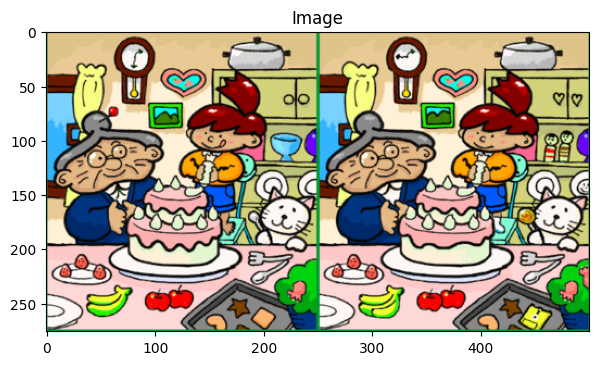

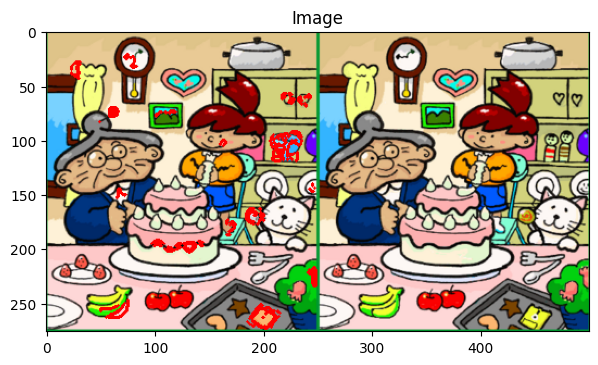

In [88]:
# 1. 픽셀 차이 (절대값)
diff = cv2.absdiff(left_img, right_img)

# 2. grayscale로 합치기 (차이 크기)
gray_diff = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

# 3. threshold (여기서 "적당히 큰 차이"만 남김)
_, mask = cv2.threshold(gray_diff, 120, 255, cv2.THRESH_BINARY)

# 4. 좌표 추출
ys, xs = np.where(mask == 255)

# 5. 시각화
vis = img.copy()
for y, x in zip(ys, xs):
    cv2.circle(vis, (x, y), 1, (0, 0, 255), -1)

cv2_imshow(img, figsize=(7,7))
cv2_imshow(vis, figsize=(7,7))

## ***MNIST 데이터보다 밝은 이미지, 어두운 이미지 인식시키기***
- Chap09에서 실패했던 MNIST데이터보다 어두운 이미지를 인식시켜봅시다
- 우리가 지금까지 배운 밝기 조정을 이용해서 인식시켜볼 수 있습니다
- 먼저 기존 데이터만 사용해서 다시 학습을 시켜봅니다

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# 데이터 로드
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 정규화 + flatten
x_train = x_train.reshape(-1, 28*28).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 28*28).astype('float32') / 255.0

tf.random.set_seed(42)
# FCN 모델 (Fully Connected Network only)
model = models.Sequential([
    layers.Input(shape=(28*28,)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 컴파일
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 학습
model.fit(x_train, y_train, epochs=3, batch_size=64, validation_split=0.1)

# 평가
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9345 - loss: 0.2151 - val_accuracy: 0.9695 - val_loss: 0.1073
Epoch 2/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9738 - loss: 0.0854 - val_accuracy: 0.9728 - val_loss: 0.0936
Epoch 3/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9825 - loss: 0.0556 - val_accuracy: 0.9757 - val_loss: 0.0879
Test Accuracy: 0.9745


### ***확인해볼 사항***
- 어두운 이미지 인식시켜보기

In [80]:
import cv2
import numpy as np

# 이미지를 흑백으로 읽기
img = cv2.imread("dark_3.png", cv2.IMREAD_GRAYSCALE)

# 2. 전처리 (28x28, 정규화)
img = cv2.resize(img, (28, 28))        # 크기 맞추기

# 3. 정규화및 모델 입력 형태 맞추기 (batch, 28, 28, 1)
img = img.reshape(-1, 28*28).astype('float32') / 255.0   # 0~1 정규화

# 4. 예측
pred = model.predict(img)
import numpy as np

np.set_printoptions(suppress=True, precision=6)
print("각 숫자별 확률:")
for i, p in enumerate(pred[0]):
    print(f"{i}: {p:.6f}")

digit = np.argmax(pred[0])
print("예측된 숫자:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
각 숫자별 확률:
0: 0.054792
1: 0.060418
2: 0.087488
3: 0.148605
4: 0.075392
5: 0.185555
6: 0.068445
7: 0.057489
8: 0.162176
9: 0.099640
예측된 숫자: 5


## ***MNIST 이미지 밝기를 조정하면 벌어지는 일***

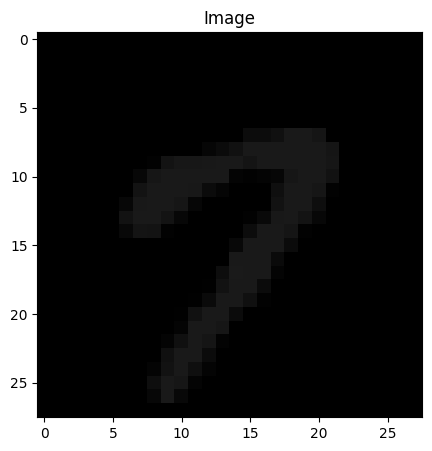

In [162]:
x_train_dark = cv2.convertScaleAbs(x_train[15], alpha=0.1, beta=0)
cv2_imshow(x_train_dark)

학습용 입력이미지: 60000장
테스트용 입력이미지: 10000장
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 115 121 162 253 253 213 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 063 107 170

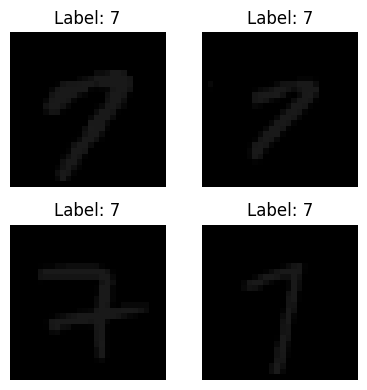

In [ ]:
import matplotlib.pyplot as plt
import math
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# =================
# 대비, 밝기 조정
# =================
contrast = 0.1
brightness = 0

# 보고 싶은 숫자 이미지
target_class = 7

# 몇 장 볼 건지
samples = 4

sqrt_samples = int(math.sqrt(samples))

print(f'학습용 입력이미지: {len(x_train)}장')
print(f'테스트용 입력이미지: {len(x_test)}장')

target_indices = []

for i in range(len(y_train)):
    if y_train[i] == target_class:
        target_indices.append(i)

# ==============================
# 시각화
# ==============================
plt.figure(figsize=(sqrt_samples * 2, sqrt_samples * 2))

for idx in range(samples):

    real_idx = target_indices[idx]

    # 픽셀값 출력
    for row in x_train[real_idx]:
        for col in row:
            print(f'{int(col):03d}', end=' ')
        print()

    print("======================================================")

    # 이미지 출력
    plt.subplot(sqrt_samples, sqrt_samples, idx + 1)
    x_train_dark = cv2.convertScaleAbs(x_train[real_idx], alpha=contrast, beta=brightness)
    plt.imshow(x_train_dark, cmap='gray', vmin=0, vmax=255)
    plt.title(f"Label: {y_train[real_idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## ***추가된 데이터와 함께 딥러닝모델 학습***

In [84]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# =================
# 대비, 밝기 조정
# =================
contrast = 0.2
brightness = 0

# 1. 데이터 로드
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. 어두운 이미지 생성 (복사 + brightness 감소)
x_train_dark = np.clip(x_train * contrast + brightness, 0, 255)
x_test_dark  = np.clip(x_test * contrast + brightness, 0, 255)

# 3. 합치기 (원본 + 어두운 버전)
x_train = np.concatenate([x_train, x_train_dark], axis=0)
y_train = np.concatenate([y_train, y_train], axis=0)

x_test = np.concatenate([x_test], axis=0)
y_test = np.concatenate([y_test], axis=0)

# 4. flatten + normalize
x_train = x_train.reshape(-1, 28*28).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 28*28).astype('float32') / 255.0

tf.random.set_seed(42)
# 5. FCN 모델
new_model = models.Sequential([
    layers.Input(shape=(28*28,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 6. 컴파일
new_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 7. 학습
new_model.fit(x_train, y_train, epochs=3, batch_size=64, validation_split=0.1)

# 8. 평가
test_loss, test_acc = new_model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9453 - loss: 0.2175 - val_accuracy: 0.9664 - val_loss: 0.0988
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9790 - loss: 0.0675 - val_accuracy: 0.9772 - val_loss: 0.0676
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9862 - loss: 0.0424 - val_accuracy: 0.9809 - val_loss: 0.0552
Test Accuracy: 0.9763


## ***테스트***
- 우선 기존 테스트 데이터를 이용한 테스트 결과는 기존 성능을 유지하고 있습니다
- 이 상태로 기존에 인식하지 못한 어두운 이미지를 인식합니다
- 그러나 밝은 이미지는 인식하지 못합니다

In [ ]:
import cv2
import numpy as np

# 이미지를 흑백으로 읽기
img = cv2.imread("dark_3.png", cv2.IMREAD_GRAYSCALE)
# img = cv2.imread("bright_9.png", cv2.IMREAD_GRAYSCALE)

# 2. 전처리 (28x28, 정규화)
img = cv2.resize(img, (28, 28))        # 크기 맞추기

# 3. 정규화및 모델 입력 형태 맞추기 (batch, 28, 28, 1)
img = img.reshape(-1, 28*28).astype('float32') / 255.0   # 0~1 정규화

# 4. 예측
pred = new_model.predict(img)
import numpy as np

np.set_printoptions(suppress=True, precision=6)
print("각 숫자별 확률:")
for i, p in enumerate(pred[0]):
    print(f"{i}: {p:.6f}")

digit = np.argmax(pred[0])
print("예측된 숫자:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
각 숫자별 확률:
0: 0.000005
1: 0.000000
2: 0.000000
3: 0.000024
4: 0.000009
5: 0.000492
6: 0.000000
7: 0.000000
8: 0.940856
9: 0.058613
예측된 숫자: 8


## ***밝은 이미지 시각화***
- 적절한 Brightness와 Contrast를 조정하기 위해 시각화를 먼저 진행합니다

학습용 입력이미지: 60000장
테스트용 입력이미지: 10000장
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 115 121 162 253 253 213 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 063 107 170

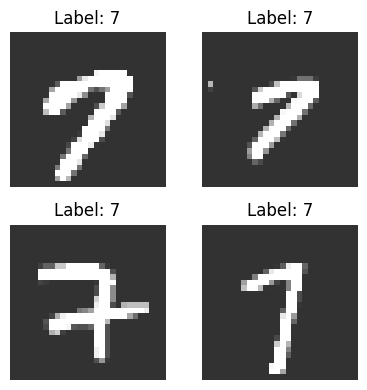

In [64]:
import matplotlib.pyplot as plt
import math
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# =================
# 대비, 밝기 조정
# =================
contrast = 1.7
brightness = 50

# 보고 싶은 숫자 이미지
target_class = 7

# 몇 장 볼 건지
samples = 4

sqrt_samples = int(math.sqrt(samples))

print(f'학습용 입력이미지: {len(x_train)}장')
print(f'테스트용 입력이미지: {len(x_test)}장')

target_indices = []

for i in range(len(y_train)):
    if y_train[i] == target_class:
        target_indices.append(i)

# ==============================
# 시각화
# ==============================
plt.figure(figsize=(sqrt_samples * 2, sqrt_samples * 2))

for idx in range(samples):

    real_idx = target_indices[idx]

    # 픽셀값 출력
    for row in x_train[real_idx]:
        for col in row:
            print(f'{int(col):03d}', end=' ')
        print()

    print("======================================================")

    # 이미지 출력
    plt.subplot(sqrt_samples, sqrt_samples, idx + 1)
    x_train_dark = cv2.convertScaleAbs(x_train[real_idx], alpha=contrast, beta=brightness)
    plt.imshow(x_train_dark, cmap='gray', vmin=0, vmax=255)
    plt.title(f"Label: {y_train[real_idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## ***밝은 이미지도 추가***
- 데이터의 규모가 3배가 됩니다

In [86]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# =================
# 대비, 밝기 조정
# =================
contrast1 = 0.2
brightness1 = 0
contrast2 = 1.7
brightness2 = 50

# 1. 데이터 로드
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2-1. 어두운 이미지 생성 (복사 + brightness 감소)
x_train_dark = np.clip(x_train * contrast1 + brightness1, 0, 255)
x_test_dark  = np.clip(x_test * contrast1 + brightness1, 0, 255)

# 2-2. 밝은 이미지 생성 (복사 + brightness 증가)
x_train_bright = np.clip(x_train * contrast2 + brightness2, 0, 255)
x_test_bright  = np.clip(x_test * contrast2 + brightness2, 0, 255)

# 3. 합치기 (원본 + 어두운 버전)
x_train = np.concatenate([x_train, x_train_dark, x_train_bright], axis=0)
y_train = np.concatenate([y_train, y_train, y_train], axis=0)

x_test = np.concatenate([x_test], axis=0)
y_test = np.concatenate([y_test], axis=0)

# 4. flatten + normalize
x_train = x_train.reshape(-1, 28*28).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 28*28).astype('float32') / 255.0

tf.random.set_seed(42)
# 5. FCN 모델
new_model2 = models.Sequential([
    layers.Input(shape=(28*28,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 6. 컴파일
new_model2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 7. 학습
new_model2.fit(x_train, y_train, epochs=3, batch_size=64, validation_split=0.1)

# 8. 평가
test_loss, test_acc = new_model2.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/3
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.9468 - loss: 0.2007 - val_accuracy: 0.9582 - val_loss: 0.1337
Epoch 2/3
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.9774 - loss: 0.0729 - val_accuracy: 0.9672 - val_loss: 0.0991
Epoch 3/3
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9850 - loss: 0.0488 - val_accuracy: 0.9676 - val_loss: 0.1028
Test Accuracy: 0.9796


### ***밝은 이미지와 어두운 이미지로 각각 테스트***
- 원본 데이터만 이용해 학습했을 때에 비해서 밝은 이미지와 어두운 이미지를 더 잘 맞추는 모습을 볼 수 있습니다
- 이 때 중요한 것은 기존 테스트 데이터를 이용한 인식 정확도를 유지하는 것입니다

In [98]:
import cv2
import numpy as np

# 이미지를 흑백으로 읽기
# img = cv2.imread("dark_3.png", cv2.IMREAD_GRAYSCALE)
img = cv2.imread("bright_9.png", cv2.IMREAD_GRAYSCALE)

# 2. 전처리 (28x28, 정규화)
img = cv2.resize(img, (28, 28))        # 크기 맞추기

# 3. 정규화및 모델 입력 형태 맞추기 (batch, 28, 28, 1)
img = img.reshape(-1, 28*28).astype('float32') / 255.0   # 0~1 정규화

# 4. 예측
pred = new_model2.predict(img)
import numpy as np

np.set_printoptions(suppress=True, precision=6)
print("각 숫자별 확률:")
for i, p in enumerate(pred[0]):
    print(f"{i}: {p:.6f}")

digit = np.argmax(pred[0])
print("예측된 숫자:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
각 숫자별 확률:
0: 0.000828
1: 0.000159
2: 0.001678
3: 0.002788
4: 0.077028
5: 0.000120
6: 0.000025
7: 0.081053
8: 0.032609
9: 0.803711
예측된 숫자: 9
